In [2]:
# скачиваем датасет
%pip install medmnist --quiet

Note: you may need to restart the kernel to use updated packages.


In [5]:
%pip install tqdm --quiet

Note: you may need to restart the kernel to use updated packages.


# MedMNIST
Это коллекция из 18 медицинских датасетов, предварительно обработанных до стандартизированного формата (28×28 пикселей для 2D, 28×28×28 для 3D), аналогичного классическому MNIST. Проект предназначен для быстрого прототипирования, обучения и бенчмаркинга моделей машинного обучения на медицинских изображениях.

## 2D датасеты MedMNIST (28×28 пикселей)

| Флаг (class) | Название | Модальность | Задача | Классов | Изображений | Каналы |
|:-------------|:----------|:------------|:-------|--------:|------------:|-------:|
| `pathmnist` | PathMNIST | Гистопатология (лимфоузлы, рак молочной железы) | Многоклассовая | 9 | ~107,000 | 3 (RGB) |
| `octmnist` | OCTMNIST | Оптическая когерентная томография (сетчатка) | Многоклассовая | 4 | ~109,000 | 1 |
| `pneumoniamnist` | PneumoniaMNIST | Рентген грудной клетки | Бинарная | 2 | ~5,856 | 1 |
| `chestmnist` | ChestMNIST | Рентген грудной клетки | Мультиметка (14 патологий) | 14 | ~112,000 | 1 |
| `dermamnist` | DermaMNIST | Дерматоскопия (кожные поражения) | Многоклассовая | 7 | ~10,015 | 3 (RGB) |
| `retinamnist` | RetinaMNIST | Фундус-фотография (диабетическая ретинопатия) | Многоклассовая | 5 | ~1,600 | 3 (RGB) |
| `breastmnist` | BreastMNIST | УЗИ молочной железы | Многоклассовая | 3 | ~1,200 | 1 |
| `bloodmnist` | BloodMNIST | Микроскопия крови (типы лейкоцитов) | Многоклассовая | 8 | ~17,000 | 3 (RGB) |
| `tissuemnist` | TissueMNIST | Микроскопия биопсии почек | Многоклассовая | 8 | ~236,000 | 1 |
| `organamnist` | OrganAMNIST | КТ-срезы (осевая проекция) | Многоклассовая | 11 | ~58,000 | 1 |
| `organcmnist` | OrganCMNIST | КТ-срезы (корональная проекция) | Многоклассовая | 11 | ~58,000 | 1 |
| `organsmnist` | OrganSMNIST | КТ-срезы (сагиттальная проекция) | Многоклассовая | 11 | ~58,000 | 1 |



## 3D датасеты MedMNIST (28×28×28 вокселей)

| Флаг (class) | Название | Модальность | Задача | Классов | Образцов | Каналы |
|:-------------|:----------|:------------|:-------|--------:|---------:|-------:|
| `organmnist3d` | OrganMNIST3D | Компьютерная томография (сегментированные органы) | Многоклассовая | 11 | ~2,800 | 1 |
| `nodulemnist3d` | NoduleMNIST3D | КТ (легочные узелки) | Бинарная | 2 | ~1,600 | 1 |
| `adrenalmnist3d` | AdrenalMNIST3D | КТ (надпочечники) | Бинарная | 2 | ~1,300 | 1 |
| `fracturemnist3d` | FractureMNIST3D | КТ (позвоночник, переломы) | Бинарная | 2 | ~1,000 | 1 |
| `vesselmnist3d` | VesselMNIST3D | Магнитно-резонансная ангиография (сосуды мозга) | Бинарная | 2 | ~1,300 | 1 |
| `synapsemnist3d` | SynapseMNIST3D | Электронная микроскопия (синапсы) | Бинарная | 2 | ~1,500 | 1 |



## Задачи

| Тип задачи | 2D датасеты | 3D датасеты |
|:-----------|:------------|:------------|
| **Бинарная классификация** | PneumoniaMNIST | NoduleMNIST3D, AdrenalMNIST3D, FractureMNIST3D, VesselMNIST3D, SynapseMNIST3D |
| **Многоклассовая классификация** | PathMNIST, OCTMNIST, DermaMNIST, RetinaMNIST, BreastMNIST, BloodMNIST, TissueMNIST, OrganA/C/SMNIST | OrganMNIST3D |
| **Мультиметка (14 классов)** | ChestMNIST | — |


In [20]:
from tqdm import tqdm
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms

import medmnist
from medmnist import INFO, Evaluator

# 28 X 28

In [7]:
data_flag = 'pathmnist'
# data_flag = 'breastmnist'
download = True

NUM_EPOCHS = 3
BATCH_SIZE = 128
lr = 0.001

info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

DataClass = getattr(medmnist, info['python_class'])

In [8]:
# preprocessing
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

# load the data
train_dataset = DataClass(split='train', transform=data_transform, download=download)
test_dataset = DataClass(split='test', transform=data_transform, download=download)

pil_dataset = DataClass(split='train', download=download)

# encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
train_loader_at_eval = data.DataLoader(dataset=train_dataset, batch_size=2*BATCH_SIZE, shuffle=False)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=2*BATCH_SIZE, shuffle=False)

100%|██████████| 206M/206M [00:51<00:00, 3.96MB/s] 


In [9]:
print(train_dataset)
print("===================")
print(test_dataset)

Dataset PathMNIST of size 28 (pathmnist)
    Number of datapoints: 89996
    Root location: /Users/evakhromeeva/.medmnist
    Split: train
    Task: multi-class
    Number of channels: 3
    Meaning of labels: {'0': 'adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'}
    Number of samples: {'train': 89996, 'val': 10004, 'test': 7180}
    Description: The PathMNIST is based on a prior study for predicting survival from colorectal cancer histology slides, providing a dataset (NCT-CRC-HE-100K) of 100,000 non-overlapping image patches from hematoxylin & eosin stained histological images, and a test dataset (CRC-VAL-HE-7K) of 7,180 image patches from a different clinical center. The dataset is comprised of 9 types of tissues, resulting in a multi-class classification task. We resize the source images of 3×224×224 into 3×28×28, and split N

In [10]:
# visualization

train_dataset.montage(length=1)

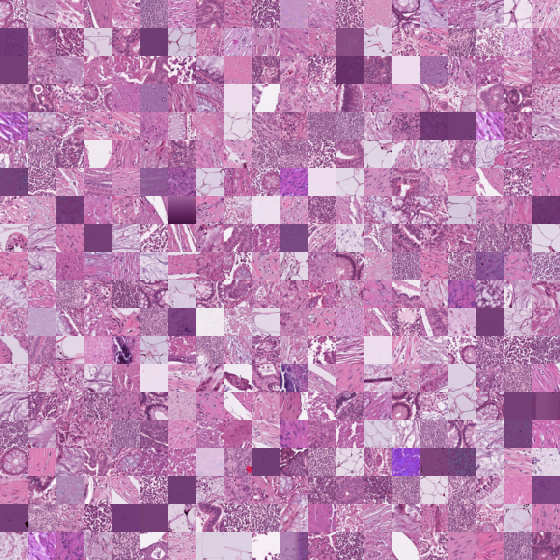

In [11]:
# montage

train_dataset.montage(length=20)

In [21]:
# define a simple CNN model

class Net(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(Net, self).__init__()

        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3),
            nn.BatchNorm2d(16),
            nn.ReLU())

        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 16, kernel_size=3),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))

        self.layer3 = nn.Sequential(
            nn.Conv2d(16, 64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU())
        
        self.layer4 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU())

        self.layer5 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))

        self.fc = nn.Sequential(
            nn.Linear(64 * 4 * 4, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes))

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model = Net(in_channels=n_channels, num_classes=n_classes)
    
# define loss function and optimizer
if task == "multi-label, binary-class":
    criterion = nn.BCEWithLogitsLoss()
else:
    criterion = nn.CrossEntropyLoss()
    
optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)

In [14]:
for epoch in range(NUM_EPOCHS):
    train_correct = 0
    train_total = 0
    test_correct = 0
    test_total = 0
    
    model.train()
    for inputs, targets in tqdm(train_loader):
        # forward + backward + optimize
        optimizer.zero_grad()
        outputs = model(inputs)
        
        if task == 'multi-label, binary-class':
            targets = targets.to(torch.float32)
            loss = criterion(outputs, targets)
        else:
            targets = targets.squeeze().long()
            loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()

100%|██████████| 704/704 [01:04<00:00, 10.93it/s]


In [15]:
# evaluation

def test(split):
    model.eval()
    y_true = torch.tensor([])
    y_score = torch.tensor([])
    
    data_loader = train_loader_at_eval if split == 'train' else test_loader

    with torch.no_grad():
        for inputs, targets in data_loader:
            outputs = model(inputs)

            if task == 'multi-label, binary-class':
                targets = targets.to(torch.float32)
                outputs = outputs.softmax(dim=-1)
            else:
                targets = targets.squeeze().long()
                outputs = outputs.softmax(dim=-1)
                targets = targets.float().resize_(len(targets), 1)

            y_true = torch.cat((y_true, targets), 0)
            y_score = torch.cat((y_score, outputs), 0)

        y_true = y_true.numpy()
        y_score = y_score.detach().numpy()
        
        evaluator = Evaluator(data_flag, split)
        metrics = evaluator.evaluate(y_score)
    
        print('%s  auc: %.3f  acc:%.3f' % (split, *metrics))

        
print('==> Evaluating ...')
test('train')
test('test')

==> Evaluating ...
train  auc: 0.974  acc:0.735
test  auc: 0.932  acc:0.630


# 224 X 224

(!) здесь будет долгая загрузка данных, т.к. разрешение изображений намного больше

In [ ]:
data_flag = 'pathmnist'
download = True

info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

# load the data
train_dataset = DataClass(split='train', transform=data_transform, download=download, size=224, mmap_mode='r')

# encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [ ]:
x, y = train_dataset[0]

print(x.shape, y.shape)

In [ ]:
train_dataset.montage(length=3)

In [ ]:
from torchvision.models import resnet18

model = resnet18(num_classes=n_classes).cuda()

criterion = nn.CrossEntropyLoss()
    
optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)

In [ ]:
# train

for epoch in range(NUM_EPOCHS):
    train_correct = 0
    train_total = 0
    test_correct = 0
    test_total = 0
    
    model.train()
    for inputs, targets in tqdm(train_loader):
        # forward + backward + optimize
        optimizer.zero_grad()
        outputs = model(inputs.cuda())
        targets = targets.cuda()
        
        if task == 'multi-label, binary-class':
            targets = targets.to(torch.float32)
            loss = criterion(outputs, targets)
        else:
            targets = targets.squeeze().long()
            loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()

In [ ]:
split = 'test'

model.eval()
y_true = torch.tensor([])
y_score = torch.tensor([])

data_loader = train_loader_at_eval if split == 'train' else test_loader

with torch.no_grad():
    for inputs, targets in data_loader:
        inputs = inputs.cuda()
        outputs = model(inputs)
        outputs = outputs.softmax(dim=-1)
        y_score = torch.cat((y_score, outputs.cpu()), 0)

    y_score = y_score.detach().numpy()
    
    evaluator = Evaluator(data_flag, split, size=224)
    metrics = evaluator.evaluate(y_score)

    print('%s  auc: %.3f  acc: %.3f' % (split, *metrics))

# 28x28x28

In [23]:
data_flag = 'organmnist3d'
download = True

info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

# load the data
train_dataset = DataClass(split='train', download=download)

# encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)

100%|██████████| 32.7M/32.7M [00:06<00:00, 5.06MB/s]


In [24]:
x, y = train_dataset[0]

print(x.shape, y.shape)

(1, 28, 28, 28) (1,)


In [25]:
for x, y in train_loader:
    print(x.shape, y.shape)
    break

torch.Size([128, 1, 28, 28, 28]) torch.Size([128, 1])


In [26]:
frames = train_dataset.montage(length=1, save_folder="tmp/")
frames[10]

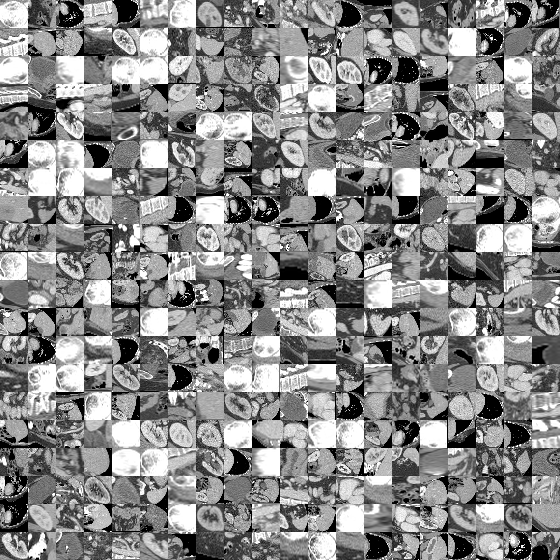

In [27]:
frames = train_dataset.montage(length=20, save_folder="tmp/")

frames[10]

# 64x64x64

(!) здеь тоже будет долгая загрузка из-за размера

In [ ]:
data_flag = 'organmnist3d'
download = True

info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

# load the data
train_dataset = DataClass(split='train', download=download, size=64)

# encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [ ]:
x, y = train_dataset[0]

print(x.shape, y.shape)

In [ ]:
for x, y in train_loader:
    print(x.shape, y.shape)
    break

In [ ]:
frames = train_dataset.montage(length=8, save_folder="tmp/")

frames[10]